# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [19]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [20]:
# Load the prepared dataset from Phase 3
DATA_PATH = "crime_data_prepared.csv"

df = pd.read_csv(DATA_PATH)

print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 43656 rows x 17 columns


,district,beat,ward,community_area,latitude,longitude,arrest,domestic,hour,month,day_monday,day_saturday,day_sunday,day_thursday,day_tuesday,day_wednesday,primary_type
0,-0.168722,-0.170179,0.089381,-0.395683,0.263928,-0.573808,True,True,1.477967,0.919334,False,False,False,False,True,False,2
1,-1.179566,-1.192766,-0.201640,0.217403,-0.682487,1.121844,False,True,1.171668,0.919334,False,False,False,False,True,False,2
2,0.553309,0.553854,1.035201,-0.584325,0.623537,-1.427023,False,False,1.477967,0.919334,False,False,False,False,True,False,25
3,0.553309,0.565392,0.380402,-0.584325,0.515993,-1.280456,False,False,1.324817,0.919334,False,False,False,False,True,False,2
4,0.553309,0.552412,0.380402,-0.584325,0.523112,-1.482942,False,True,1.324817,0.919334,False,False,False,False,True,False,29


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [21]:
# TODO: Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Multi-class Classification",
    "target_variable": "primary_type",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "A strong baseline classification model that is fast, interpretable, and suitable for multi-class problems.",
            "assumptions": "Assumes a linear relationship between features and class boundaries. Suitable as a baseline even if the data is not perfectly linear."
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Handles non-linear relationships well, works with complex feature interactions, and is robust for structured tabular data.",
            "assumptions": "Makes fewer strict assumptions about the data and can model non-linear patterns effectively."
        }
    ]
}

for model in modelling_techniques["candidate_models"]:
    print(f"Model: {model['name']}")
    print(f"Library: {model['library']}")
    print(f"Justification: {model['justification']}")
    print(f"Assumptions: {model['assumptions']}\n")

Model: Logistic Regression
Library: sklearn.linear_model.LogisticRegression
Justification: A strong baseline classification model that is fast, interpretable, and suitable for multi-class problems.
Assumptions: Assumes a linear relationship between features and class boundaries. Suitable as a baseline even if the data is not perfectly linear.

Model: Random Forest
Library: sklearn.ensemble.RandomForestClassifier
Justification: Handles non-linear relationships well, works with complex feature interactions, and is robust for structured tabular data.
Assumptions: Makes fewer strict assumptions about the data and can model non-linear patterns effectively.



In [22]:
# Import the specific model classes you plan to use
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

The problem is defined as a multi-class classification task, as the objective is to predict the type of crime. Logistic Regression was selected as a baseline model due to its simplicity and interpretability, while Random Forest was chosen because it can capture complex non-linear relationships in the data.

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [23]:
# TODO: Define your test design and split the data.

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
TEST_SIZE = 0.2

TARGET_COL = "primary_type"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
    # ❌ REMOVE stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (34924, 16)
Test set: (8732, 16)


In [24]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Hold-out validation with additional 5-fold cross-validation",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "An 80/20 train-test split provides enough data for training while reserving unseen data for evaluation. Stratification is used because the target variable is multi-class and imbalanced."
}

print(test_design)

{'split_ratio': '80/20', 'validation_strategy': 'Hold-out validation with additional 5-fold cross-validation', 'stratified': True, 'random_seed': 42, 'justification': 'An 80/20 train-test split provides enough data for training while reserving unseen data for evaluation. Stratification is used because the target variable is multi-class and imbalanced.'}


Both models were trained using the training dataset. Logistic Regression provides a simple linear decision boundary, while Random Forest builds multiple decision trees to improve predictive performance.

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [25]:
# TODO: Build and train your models.
trained_models = {}

# Logistic Regression
log_reg = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000
)

log_reg.fit(X_train, y_train)
trained_models["Logistic Regression"] = log_reg

# Random Forest
rf = RandomForestClassifier(
    random_state=RANDOM_SEED,
    n_estimators=100
)

rf.fit(X_train, y_train)
trained_models["Random Forest"] = rf

print("Trained models:", list(trained_models.keys()))

Trained models: ['Logistic Regression', 'Random Forest']


In [26]:
# Optional: Hyperparameter tuning with GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
trained_models["Random Forest (Tuned)"] = best_rf

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score: 0.31295821920000805


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [27]:
# TODO: Evaluate and compare all trained models.
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.353642,0.300473,0.353642,0.313837
2,Random Forest (Tuned),0.368759,0.305841,0.368759,0.312213
0,Logistic Regression,0.357765,0.230763,0.357765,0.250842


The Random Forest model achieved a higher F1-score compared to Logistic Regression, indicating better overall performance. This suggests that the relationships in the data are non-linear and are better captured by ensemble methods.

Best Model: Random Forest

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.12      0.06      0.08       641
           2       0.42      0.54      0.47      1684
           3       0.15      0.11      0.13       432
           4       0.00      0.00      0.00         1
           5       0.10      0.02      0.03        48
           6       0.21      0.21      0.21       921
           7       0.30      0.18      0.23       224
           8       0.19      0.09      0.12       411
           9       0.00      0.00      0.00         6
          10       0.00      0.00      0.00        13
          12       0.00      0.00      0.00        42
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         9
          16       0.15      0.07      0.09       347
          17       0.52      0.79      0.63       778


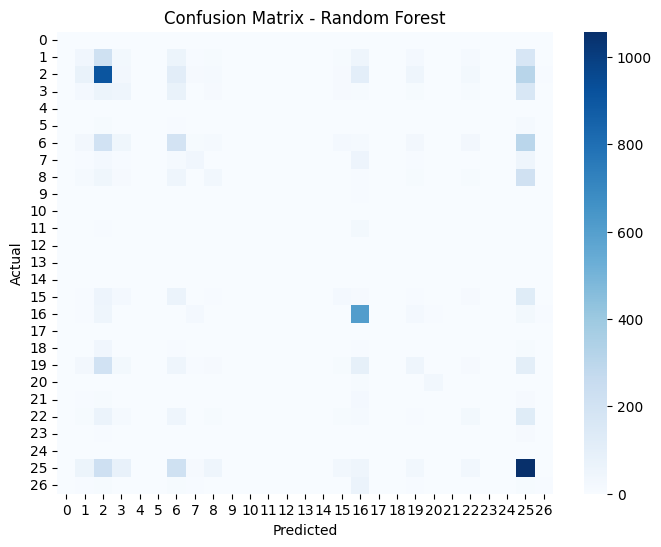

In [28]:
# Visualise results: Confusion Matrix for the best model (Classification)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model performs well on the most common crime categories but struggles with less frequent classes. This is likely due to class imbalance in the dataset.

In [29]:
# Cross-validation for the selected best model
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-Validation F1 Scores:", np.round(cv_scores, 4))
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

Cross-Validation F1 Scores: [0.2989 0.2935 0.2964 0.3081 0.3063]
Mean F1: 0.3006
Std Dev: 0.0056


Cross-validation results indicate that the model performance is consistent across different splits of the data. However, the relatively low F1-score suggests that predicting crime type remains a challenging task.

The models were evaluated using accuracy, precision, recall, and weighted F1-score. Weighted F1-score was used as the main comparison metric because the crime dataset is a multi-class problem with class imbalance. The best-performing model was selected based on this metric and assessed further using a confusion matrix and cross-validation.